In [1]:
%load_ext autoreload
%autoreload 2

In [15]:
import numpy as np
import random

import pickle as pkl
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainwidemap import bwm_query, bwm_units, load_good_units, load_trials_and_mask
from tqdm import tqdm
from one.api import ONE
from brainbox.singlecell import bin_spikes2D
from iblatlas.regions import BrainRegions
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [16]:
from ibl_info.utils import check_config

In [17]:
config = check_config()
MY_REGIONS = config["stim_prior_regions"]
MIN_NEURONS = config["min_units"]
BIN_SIZE = 0.0125
STRIDE = 0.002
USE_SLIDING_WINDOW = True

EPOCHS = {
    "Quiescent": {"align": "stimOn_times", "window": (0.6, 0.0)},
    "Stimulus": {"align": "stimOn_times", "window": (0.0, 0.15)},
    "Choice": {"align": "firstMovement_times", "window": (0.15, 0.0)},
}

In [18]:
with open("../data/generated/manifold/bwm_accumulated_data.pkl", "rb") as f:
    dx = pkl.load(f)

In [19]:
from ibl_info.manifold import plot_pcas_and_euclids

In [ ]:
session_matrix = dx["ACAd"]["Choice"]
pop_matrix = np.vstack(session_matrix)
n_bins = int(pop_matrix.shape[1] / 4)

In [27]:
accumulated_data = dx

In [22]:
reshaped = np.transpose(pop_matrix.reshape(pop_matrix.shape[0], 4, n_bins), (1, 2, 0))

In [23]:
config = check_config()

In [24]:
from scipy.spatial.distance import pdist

In [25]:
from scipy.cluster.hierarchy import dendrogram, linkage

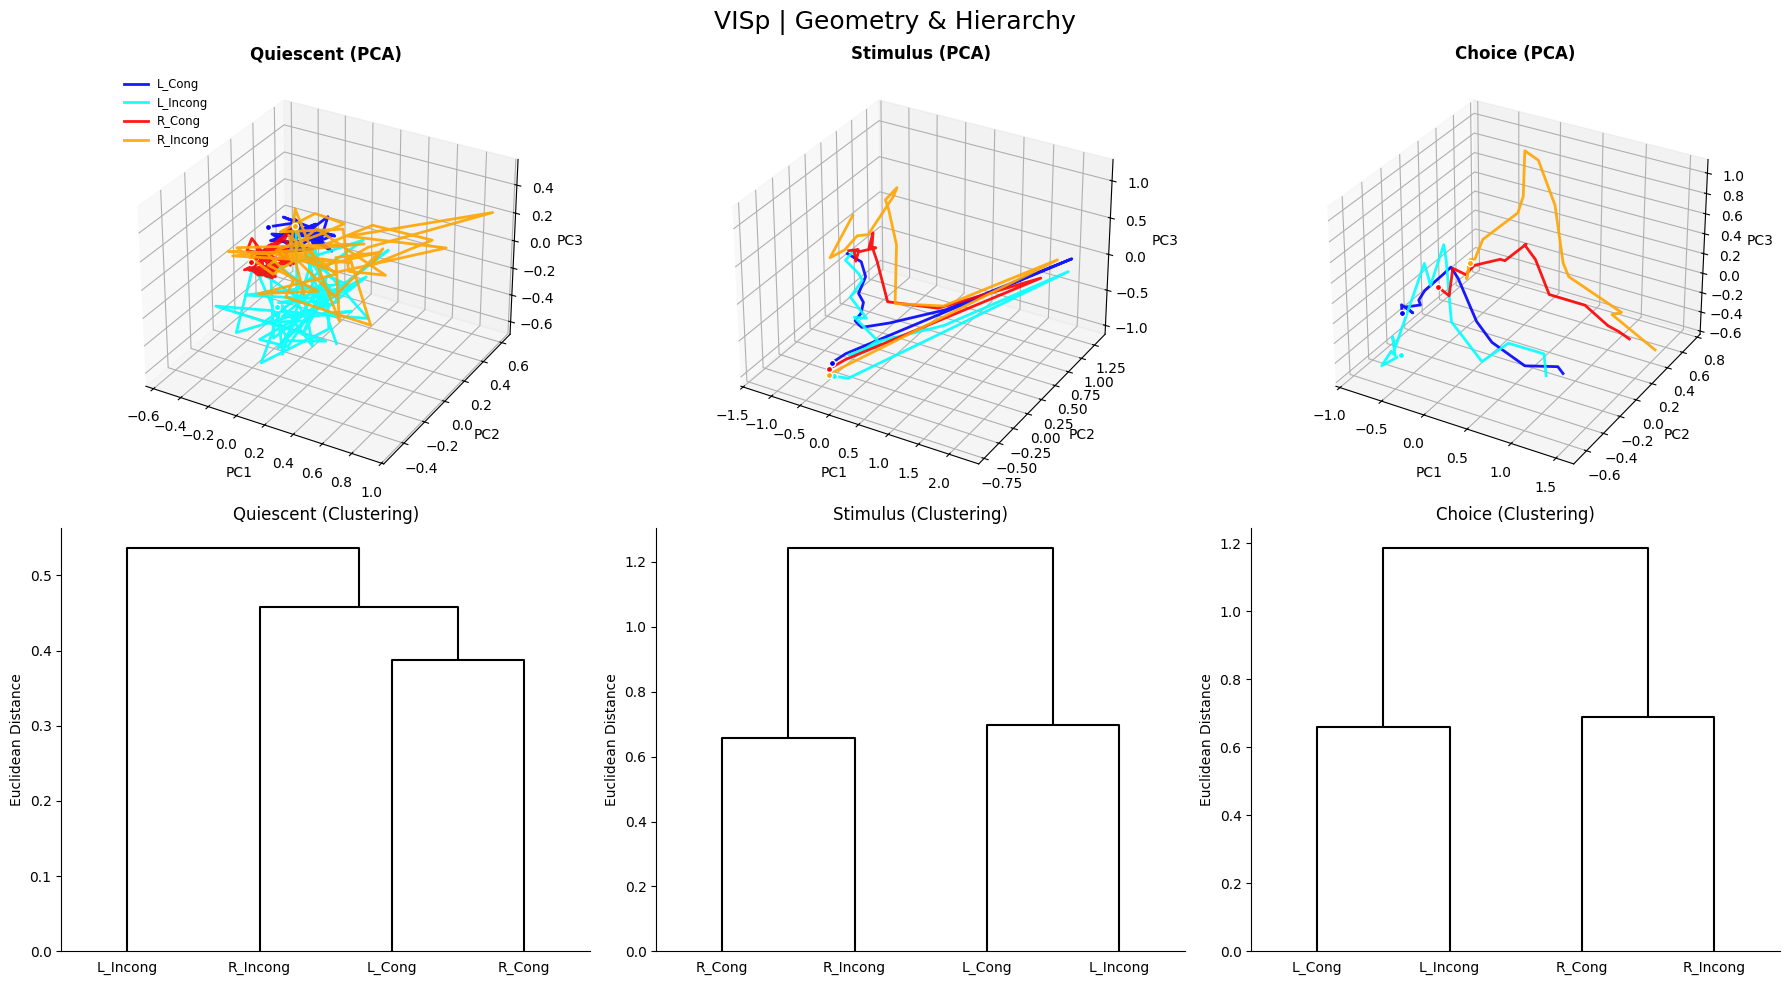

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# --- Configuration ---
epochs_ordered = ["Quiescent", "Stimulus", "Choice"]
labels = ["L_Cong", "L_Incong", "R_Cong", "R_Incong"]  # Your conditions
colors = ["blue", "cyan", "red", "orange"]  # Your COLORS list


for region in accumulated_data.keys():
    # Create Figure: 2 Rows (PCA, Dendrogram) x 3 Columns (Epochs)
    fig = plt.figure(figsize=(18, 10))
    fig.suptitle(f"{region} | Geometry & Hierarchy", fontsize=18, y=0.98)

    for i, epoch_name in enumerate(epochs_ordered):
        session_matrices = accumulated_data[region][epoch_name]
        if not session_matrices:
            continue

        # --- 1. Common Data Prep ---
        # pop_matrix shape: (Neurons, Total_Time_Bins)
        # Assumes time is concatenated: [Cond0 | Cond1 | Cond2 | Cond3]
        pop_matrix = np.vstack(session_matrices)
        n_neurons = pop_matrix.shape[0]
        n_total_bins = pop_matrix.shape[1]
        n_bins = int(n_total_bins / 4)

        # --- 2. Top Row: PCA State Space ---
        ax_pca = fig.add_subplot(2, 3, i + 1, projection="3d")

        # PCA on the transposed matrix (Samples=Time, Features=Neurons)
        pca = PCA(n_components=3)
        X_embedded = pca.fit_transform(pop_matrix.T)  # Shape: (Total_Time, 3)

        # Reshape for plotting: (4 Conditions, Time_Bins, 3 PCs)
        trajs = X_embedded.reshape(4, n_bins, 3)

        for c in range(4):
            # Plot Trajectory
            ax_pca.plot(
                trajs[c, :, 0],
                trajs[c, :, 1],
                trajs[c, :, 2],
                color=colors[c],
                label=labels[c],
                lw=2,
                alpha=0.9,
            )
            # Mark Start Point (Time 0)
            ax_pca.scatter(
                trajs[c, 0, 0],
                trajs[c, 0, 1],
                trajs[c, 0, 2],
                color=colors[c],
                s=20,
                edgecolors="white",
            )

        ax_pca.set_title(f"{epoch_name} (PCA)", fontsize=12, fontweight="bold")
        ax_pca.set_xlabel("PC1")
        ax_pca.set_ylabel("PC2")
        ax_pca.set_zlabel("PC3")

        # Only add legend to the first plot to reduce clutter
        if i == 0:
            ax_pca.legend(loc="upper left", fontsize="small", frameon=False)

        # --- 3. Bottom Row: Dendrogram ---
        ax_dendro = fig.add_subplot(2, 3, i + 4)

        # Reshape raw data to separate conditions: (4, Time, Neurons)
        # We transpose first (Time, Neurons) then reshape
        reshaped_raw = pop_matrix.T.reshape(4, n_bins, n_neurons)

        # Calculate Mean Vector for each Condition (centroid in N-dim space)
        # Shape: (4, Neurons)
        mean_vectors = np.mean(reshaped_raw, axis=1)
        actual_distances = pdist(mean_vectors, metric="euclidean")

        # Compute Hierarchical Clustering (Ward's method on Euclidean distance)
        # Note: We use the FULL high-dimensional space here, not the PCA reduction
        Z = linkage(mean_vectors, method="ward", metric="euclidean")

        dendrogram(
            Z,
            ax=ax_dendro,
            labels=labels,
            leaf_rotation=0,
            leaf_font_size=10,
            above_threshold_color="black",
            color_threshold=0,  # Makes all lines default color (unless you want clusters colored)
        )

        ax_dendro.set_title(f"{epoch_name} (Clustering)", fontsize=12)
        ax_dendro.set_ylabel("Euclidean Distance")

        # Remove top/right spines for cleaner look
        ax_dendro.spines["right"].set_visible(False)
        ax_dendro.spines["top"].set_visible(False)

        plt.tight_layout()
    plt.show()
    break

In [39]:
import scipy

corr_score = []
for region in accumulated_data.keys():
    # Create Figure: 2 Rows (PCA, Dendrogram) x 3 Columns (Epochs)
    temp = []
    for i, epoch_name in enumerate(epochs_ordered):
        session_matrices = accumulated_data[region][epoch_name]
        ideal_prior = [
            1,  # d(0,1): L_C vs L_I (Different Block)
            1,  # d(0,2): L_C vs R_C (Different Block)
            0,  # d(0,3): L_C vs R_I (SAME Block - Left Context) -> Should be close!
            0,  # d(1,2): L_I vs R_C (SAME Block - Right Context) -> Should be close!
            1,  # d(1,3): L_I vs R_I (Different Block)
            1,  # d(2,3): R_C vs R_I (Different Block)
        ]

        pop_matrix = np.vstack(session_matrices)
        n_neurons = pop_matrix.shape[0]
        n_total_bins = pop_matrix.shape[1]
        n_bins = int(n_total_bins / 4)
        reshaped_raw = pop_matrix.T.reshape(4, n_bins, n_neurons)

        # Calculate Mean Vector for each Condition (centroid in N-dim space)
        # Shape: (4, Neurons)
        mean_vectors = np.mean(reshaped_raw, axis=1)
        actual_distances = pdist(mean_vectors, metric="euclidean")
        corr, _ = scipy.stats.pearsonr(actual_distances, ideal_prior)

        temp.append(corr)
    corr_score.append(temp)

In [43]:
ideal_prior

[1, 1, 0, 0, 1, 1]

In [44]:
ideal_choice = [0, 1, 1, 1, 1, 0]

<Axes: >

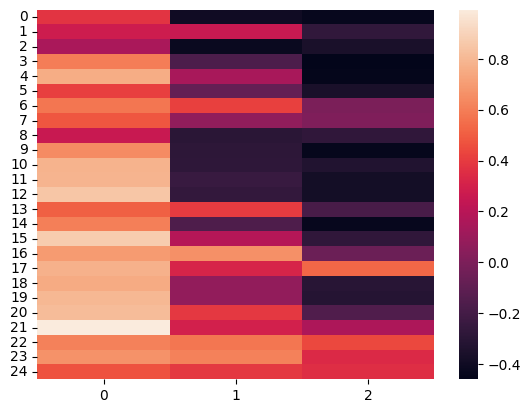

In [42]:
sns.heatmap(corr_score)